# GeoMarket-VLC · Modelado y Análisis
**Asignatura:** Evaluación, Despliegue y Monitorización de Modelos (EDM)

**Objetivo:** Construir los modelos de Machine Learning sobre el GeoDataFrame unificado.

**Estructura del notebook:**
1. Carga de datos y preparación
2. Análisis exploratorio (EDA)
3. **Tema 1** — Clasificador de Oferta Insuficiente (RF + XGBoost) con evaluación robusta
4. **Tema 2** — Score de Idoneidad para Emprendedores + Ensemble Stacking
5. **Tema 3** — Explicabilidad con SHAP (XAI)
6. Serialización de modelos para la app Streamlit

## 0. Instalación de dependencias

In [1]:
# Ejecuta solo si no tienes estas librerías instaladas
!pip install scikit-learn xgboost shap matplotlib seaborn joblib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import subprocess
subprocess.run(['pip', 'install', 'scipy', '--upgrade'], check=True)

CompletedProcess(args=['pip', 'install', 'scipy', '--upgrade'], returncode=0)

## 1. Imports y carga del CSV de features

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)

# XGBoost y SHAP
import xgboost as xgb
import shap

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Directorios
DATA_DIR = Path('..')
MODELS_DIR = Path('./models')
MODELS_DIR.mkdir(exist_ok=True)

# Estilo gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90

In [7]:
df = pd.read_csv(DATA_DIR / 'output/geomarket_vlc_features.csv', encoding='utf-8-sig')
print(f'Shape: {df.shape}')
print(f'Barrios: {len(df)}')
print(f'Target: {df["oferta_insuficiente"].value_counts().to_dict()}')
df.head(3)

Shape: (87, 62)
Barrios: 87
Target: {0: 65, 1: 22}


,coddistbar,codbarrio,coddistrit,nombre,Ind_Equip,Vul_Equip,Ind_Dem,Vul_Dem,Ind_Econom,Vul_Econom,...,demo_edad_90+,demo_pct_joven,demo_pct_mayor,demo_total_distrito,sin_dato_vulnerabilidad,densidad_locales_hab,accesibilidad_tp,area_km2,densidad_locales_km2,oferta_insuficiente
0,93,3,9,LA CREU COBERTA,1.6,Vulnerabilidad Media,3.6,Vulnerabilidad Baja,2.5,Vulnerabilidad Baja,...,535.0,22.18,20.42,52623.0,0,0.006171,8.0,0.374885,101.364297,1
1,104,4,10,LA FONTETA S.LLUIS,1.6,Vulnerabilidad Media,3.7,Vulnerabilidad Baja,2.2,Vulnerabilidad Media,...,723.0,23.43,20.80,73915.0,0,0.013220,8.0,0.238824,163.299885,0
2,142,2,14,CAMI DE VERA,1.4,Vulnerabilidad Alta,4.1,Vulnerabilidad Baja,3.3,Vulnerabilidad Baja,...,301.0,21.55,21.72,28718.0,0,0.014412,4.0,0.827032,94.313160,0


## 2. Análisis exploratorio (EDA)
Antes de modelar, entendemos la estructura de los datos y el desbalanceo del target.

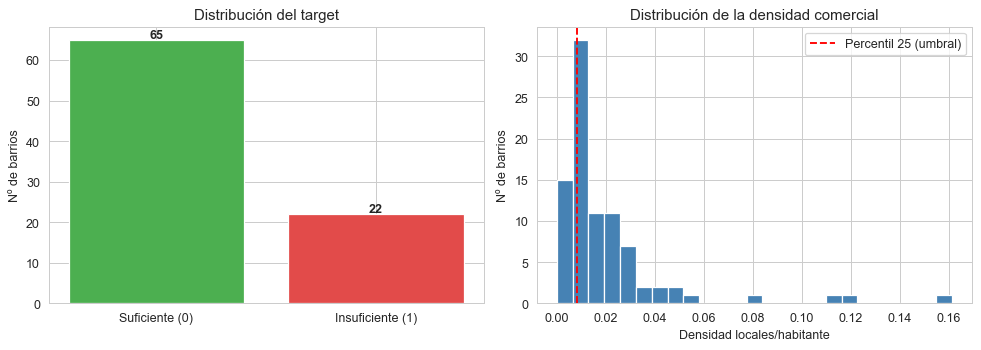

Desbalanceo: 25.3% en clase 1 (Insuficiente)
→ Justifica usar F1/ROC-AUC en lugar de accuracy


In [8]:
# Resumen del desbalanceo del target
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Distribución del target
target_counts = df['oferta_insuficiente'].value_counts()
axes[0].bar(['Suficiente (0)', 'Insuficiente (1)'], target_counts.values,
            color=['#4CAF50', '#E24B4A'])
axes[0].set_title('Distribución del target')
axes[0].set_ylabel('Nº de barrios')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Densidad de locales por habitante
axes[1].hist(df['densidad_locales_hab'].dropna(), bins=25, color='steelblue', edgecolor='white')
axes[1].axvline(df['densidad_locales_hab'].quantile(0.25), color='red', linestyle='--',
                label=f'Percentil 25 (umbral)')
axes[1].set_xlabel('Densidad locales/habitante')
axes[1].set_ylabel('Nº de barrios')
axes[1].set_title('Distribución de la densidad comercial')
axes[1].legend()

plt.tight_layout()
plt.show()

pct_clase1 = (df['oferta_insuficiente'] == 1).mean() * 100
print(f'Desbalanceo: {pct_clase1:.1f}% en clase 1 (Insuficiente)')
print('→ Justifica usar F1/ROC-AUC en lugar de accuracy')

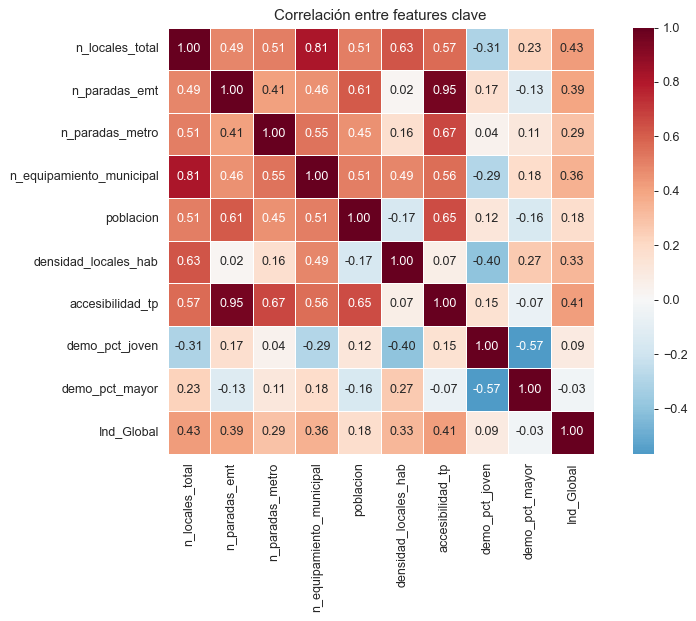

In [9]:
# Matriz de correlación entre features numéricas clave
features_clave = [
    'n_locales_total', 'n_paradas_emt', 'n_paradas_metro',
    'n_equipamiento_municipal', 'poblacion', 'densidad_locales_hab',
    'accesibilidad_tp', 'demo_pct_joven', 'demo_pct_mayor', 'Ind_Global'
]
features_disp = [c for c in features_clave if c in df.columns]

fig, ax = plt.subplots(figsize=(10, 7))
corr = df[features_disp].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlación entre features clave')
plt.tight_layout()
plt.show()

## 3. Preparación del dataset para modelado
Seleccionamos features, eliminamos columnas leak (las que definen directamente el target) y separamos X/y.

In [10]:
# IMPORTANTE: excluimos 'densidad_locales_hab' porque define directamente el target
# (sería data leakage). El modelo debe aprender a predecir insuficiencia a partir de
# las variables subyacentes (locales por tipo, transporte, demografía...).

feat_drop = [
    'oferta_insuficiente',     # target
    'densidad_locales_hab',    # leak: el target se calcula de aquí
    'nombre', 'codbarrio', 'coddistrit', 'coddistbar',  # identificadores
    'Vul_Equip', 'Vul_Dem', 'Vul_Econom', 'Vul_Global',  # categóricas redundantes con sus Ind_*
    'sin_dato_vulnerabilidad',
]

# Solo nos quedamos con las columnas que tengan datos
X_full = df.drop(columns=[c for c in feat_drop if c in df.columns])
# Solo numéricas
X_full = X_full.select_dtypes(include=[np.number])

# Imputamos nulos de los índices de vulnerabilidad (17 barrios sin dato)
# con la mediana — mejor que descartarlos
for col in X_full.columns:
    if X_full[col].isnull().any():
        X_full[col] = X_full[col].fillna(X_full[col].median())

y = df['oferta_insuficiente']

# Solo nos quedamos con barrios que tienen target válido
mask_valido = y.notna()
X = X_full[mask_valido]
y = y[mask_valido].astype(int)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nFeatures ({len(X.columns)}):')
for c in X.columns:
    print(f'  {c}')

X shape: (87, 51)
y shape: (87,)

Features (51):
  Ind_Equip
  Ind_Dem
  Ind_Econom
  Ind_Global
  n_locales_total
  n_locales_bakery
  n_locales_bank
  n_locales_bar
  n_locales_cafe
  n_locales_clothes
  n_locales_convenience
  n_locales_fast_food
  n_locales_hairdresser
  n_locales_health_care
  n_locales_home_craft_repairs
  n_locales_leisure_education
  n_locales_otro
  n_locales_pharmacy
  n_locales_professional_services
  n_locales_restaurant
  n_locales_retail_commerce
  n_locales_supermarket_food
  n_paradas_emt
  n_paradas_metro
  n_equipamiento_municipal
  poblacion
  demo_edad_0___4
  demo_edad_05___09
  demo_edad_10___14
  demo_edad_15___19
  demo_edad_20___24
  demo_edad_25___29
  demo_edad_30___34
  demo_edad_35___39
  demo_edad_40___44
  demo_edad_45___49
  demo_edad_50___54
  demo_edad_55___59
  demo_edad_60___64
  demo_edad_65___69
  demo_edad_70___74
  demo_edad_75___79
  demo_edad_80___84
  demo_edad_85___89
  demo_edad_90+
  demo_pct_joven
  demo_pct_mayor
  demo_t

## 4. Tema 1 — Clasificador de Oferta Insuficiente

**Decisiones clave (justificación para el profesor):**
- **No usamos accuracy:** con 25% de clase positiva, un modelo trivial que diga "todos suficientes" tendría 75% accuracy y sería inútil
- **Métrica principal:** F1-score y ROC-AUC
- **Coste asimétrico:** un falso negativo (no detectar un barrio desabastecido) es socialmente peor que un falso positivo → priorizamos recall en clase 1
- **Validación:** Stratified K-Fold (5 folds) por el tamaño pequeño del dataset
- **`class_weight='balanced'`** para compensar el desbalanceo durante el entrenamiento

In [11]:
# Configuración común
N_SPLITS = 5
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Modelo 1: Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Modelo 2: XGBoost
# scale_pos_weight = (negativos / positivos) → ajusta el desbalanceo
scale_pos = (y == 0).sum() / (y == 1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print(f'scale_pos_weight para XGBoost: {scale_pos:.2f}')
print('Modelos configurados ✓')

scale_pos_weight para XGBoost: 2.95
Modelos configurados ✓


In [12]:
# Evaluación con cross-validation: probabilidades out-of-fold
y_pred_rf  = cross_val_predict(rf,  X, y, cv=cv, method='predict')
y_proba_rf = cross_val_predict(rf,  X, y, cv=cv, method='predict_proba')[:, 1]

y_pred_xgb  = cross_val_predict(xgb_clf, X, y, cv=cv, method='predict')
y_proba_xgb = cross_val_predict(xgb_clf, X, y, cv=cv, method='predict_proba')[:, 1]

# Métricas comparadas
def evaluar(nombre, y_true, y_pred, y_proba):
    print(f'\n{"="*50}')
    print(f'  {nombre}')
    print(f'{"="*50}')
    print(classification_report(y_true, y_pred, target_names=['Suficiente', 'Insuficiente']))
    print(f'  ROC-AUC: {roc_auc_score(y_true, y_proba):.3f}')
    print(f'  F1 macro: {f1_score(y_true, y_pred, average="macro"):.3f}')

evaluar('Random Forest', y, y_pred_rf, y_proba_rf)
evaluar('XGBoost', y, y_pred_xgb, y_proba_xgb)


  Random Forest
              precision    recall  f1-score   support

  Suficiente       0.92      0.83      0.87        65
Insuficiente       0.61      0.77      0.68        22

    accuracy                           0.82        87
   macro avg       0.76      0.80      0.78        87
weighted avg       0.84      0.82      0.82        87

  ROC-AUC: 0.870
  F1 macro: 0.775

  XGBoost
              precision    recall  f1-score   support

  Suficiente       0.89      0.86      0.88        65
Insuficiente       0.62      0.68      0.65        22

    accuracy                           0.82        87
   macro avg       0.76      0.77      0.76        87
weighted avg       0.82      0.82      0.82        87

  ROC-AUC: 0.843
  F1 macro: 0.764


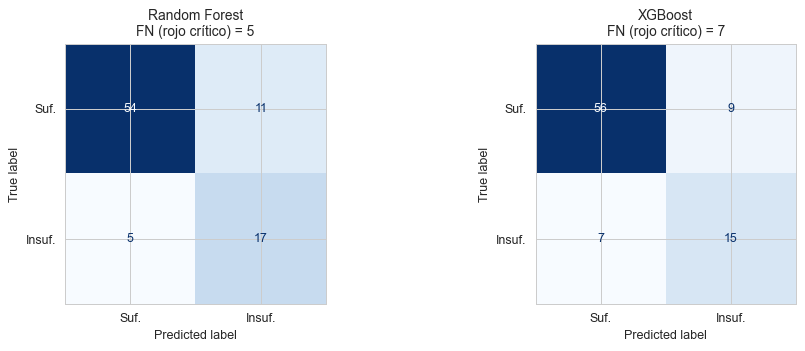

FN = Falsos Negativos: barrios desabastecidos NO detectados (coste social alto)


In [13]:
# Matrices de confusión comparadas
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (nombre, y_pred) in zip(axes, [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Suf.', 'Insuf.']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{nombre}\nFN (rojo crítico) = {cm[1,0]}',
                 fontsize=11)

plt.tight_layout()
plt.show()

print('FN = Falsos Negativos: barrios desabastecidos NO detectados (coste social alto)')

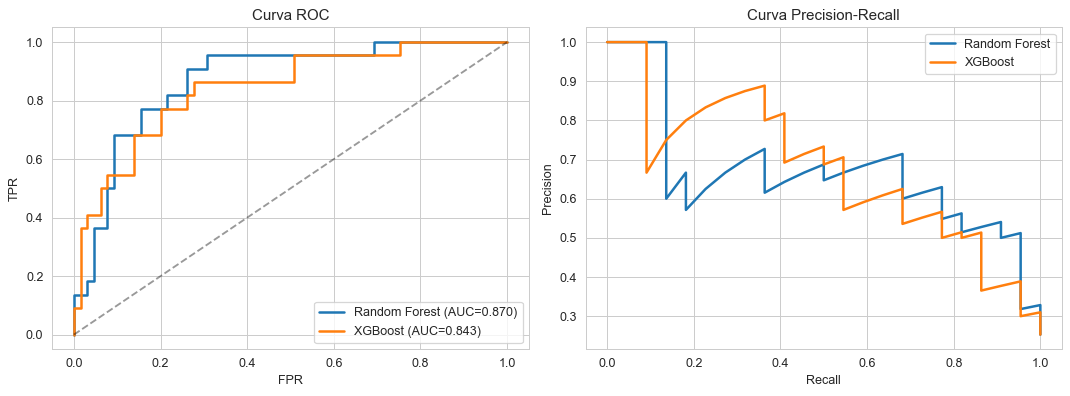

In [14]:
# Curvas ROC y Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for nombre, y_proba, color in [('Random Forest', y_proba_rf, '#1f77b4'),
                                ('XGBoost', y_proba_xgb, '#ff7f0e')]:
    # ROC
    fpr, tpr, _ = roc_curve(y, y_proba)
    auc = roc_auc_score(y, y_proba)
    axes[0].plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})', color=color, linewidth=2)
    
    # PR
    prec, rec, _ = precision_recall_curve(y, y_proba)
    axes[1].plot(rec, prec, label=nombre, color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC'); axes[0].legend()

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall'); axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Tema 2 — Ensemble Stacking (Hybrid Models)

**Principio de la "Sabiduría de las Masas":** combinamos las predicciones de RF y XGBoost mediante un meta-modelo (Logistic Regression) que aprende a ponderar las predicciones de cada uno. Esto reduce la varianza y captura distintos patrones del dato.

In [15]:
# Stacking: RF + XGBoost como base learners, LogisticRegression como meta-modelo
stack = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb_clf),
    ],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    cv=cv,
    n_jobs=-1,
    passthrough=False
)

# Evaluación del stacking
y_pred_stack  = cross_val_predict(stack, X, y, cv=cv, method='predict')
y_proba_stack = cross_val_predict(stack, X, y, cv=cv, method='predict_proba')[:, 1]

print('STACKING ENSEMBLE (RF + XGBoost → LogReg)')
print(classification_report(y, y_pred_stack, target_names=['Suficiente', 'Insuficiente']))
print(f'ROC-AUC: {roc_auc_score(y, y_proba_stack):.3f}')

# Comparativa final
resumen = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'Stacking'],
    'ROC-AUC': [roc_auc_score(y, y_proba_rf), roc_auc_score(y, y_proba_xgb), roc_auc_score(y, y_proba_stack)],
    'F1 macro': [f1_score(y, y_pred_rf, average='macro'),
                 f1_score(y, y_pred_xgb, average='macro'),
                 f1_score(y, y_pred_stack, average='macro')],
    'Recall clase 1': [f1_score(y, y_pred_rf, pos_label=1, average='binary'),
                       f1_score(y, y_pred_xgb, pos_label=1, average='binary'),
                       f1_score(y, y_pred_stack, pos_label=1, average='binary')],
}).round(3)

print('\nCOMPARATIVA FINAL:')
print(resumen.to_string(index=False))

STACKING ENSEMBLE (RF + XGBoost → LogReg)
              precision    recall  f1-score   support

  Suficiente       0.91      0.78      0.84        65
Insuficiente       0.55      0.77      0.64        22

    accuracy                           0.78        87
   macro avg       0.73      0.78      0.74        87
weighted avg       0.82      0.78      0.79        87

ROC-AUC: 0.841

COMPARATIVA FINAL:
       Modelo  ROC-AUC  F1 macro  Recall clase 1
Random Forest    0.870     0.775           0.680
      XGBoost    0.843     0.764           0.652
     Stacking    0.841     0.742           0.642


## 6. Score de Idoneidad para Emprendedores

Para el **Perfil A (Emprendedor)** construimos un score multi-criterio por barrio y por sector. La fórmula combina:

- **Baja competencia** del sector elegido (negativo: muchos competidores → mal sitio)
- **Demanda potencial** (positivo: más población → más clientes)
- **Accesibilidad** en transporte público
- **Vulnerabilidad media-baja** (penaliza zonas socioeconómicamente muy deprimidas)

Todas las variables se normalizan con MinMaxScaler para que el score esté en [0, 100].

In [16]:
# Sectores disponibles para el recomendador
sectores = [c.replace('n_locales_', '') for c in df.columns
            if c.startswith('n_locales_') and c != 'n_locales_total']
sectores = [s for s in sectores if s != 'otro']
print(f'Sectores comerciales disponibles ({len(sectores)}):')
print('  ' + ', '.join(sectores))

Sectores comerciales disponibles (16):
  bakery, bank, bar, cafe, clothes, convenience, fast_food, hairdresser, health_care, home_craft_repairs, leisure_education, pharmacy, professional_services, restaurant, retail_commerce, supermarket_food


In [17]:
def calcular_score_emprendedor(df, sector, pesos=None):
    """
    Devuelve un DataFrame con el score 0-100 por barrio para abrir un negocio del sector dado.
    
    Componentes (normalizados a [0, 1]):
      - competencia_inv: 1 - competencia (menos locales del sector = mejor)
      - demanda: población normalizada
      - accesibilidad: paradas EMT + metro
      - calidad: 1 - vulnerabilidad (mejor zona socioeconómica)
    """
    if pesos is None:
        pesos = {'competencia_inv': 0.40, 'demanda': 0.25, 'accesibilidad': 0.20, 'calidad': 0.15}
    
    col_sector = f'n_locales_{sector}'
    if col_sector not in df.columns:
        raise ValueError(f'Sector "{sector}" no encontrado')
    
    out = df[['nombre', 'codbarrio', 'coddistbar', col_sector,
              'poblacion', 'accesibilidad_tp', 'Ind_Global']].copy()
    out.columns = ['nombre', 'codbarrio', 'coddistbar', 'competencia',
                   'poblacion', 'accesibilidad', 'vulnerabilidad']
    
    # Normalización 0-1 (excluyendo barrios sin población)
    out_valid = out[out['poblacion'] > 0].copy()
    scaler = MinMaxScaler()
    
    out_valid['competencia_n']   = scaler.fit_transform(out_valid[['competencia']])
    out_valid['demanda_n']       = scaler.fit_transform(out_valid[['poblacion']])
    out_valid['accesibilidad_n'] = scaler.fit_transform(out_valid[['accesibilidad']])
    
    # Vulnerabilidad: si hay nulos, los rellenamos con la media
    out_valid['vuln_n'] = scaler.fit_transform(
        out_valid[['vulnerabilidad']].fillna(out_valid['vulnerabilidad'].mean())
    )
    
    # Score (competencia INVERSA: menos competencia = mejor)
    out_valid['score'] = (
        pesos['competencia_inv'] * (1 - out_valid['competencia_n']) +
        pesos['demanda']         * out_valid['demanda_n'] +
        pesos['accesibilidad']   * out_valid['accesibilidad_n'] +
        pesos['calidad']         * (1 - out_valid['vuln_n'])
    ) * 100
    
    return out_valid.sort_values('score', ascending=False)


# Ejemplo: recomendación para una nueva cafetería
sector_demo = 'cafe'
ranking = calcular_score_emprendedor(df, sector_demo)
print(f'TOP 10 BARRIOS RECOMENDADOS PARA ABRIR UN/A {sector_demo.upper()}\n')
print(ranking[['nombre', 'competencia', 'poblacion', 'accesibilidad', 'score']]
      .head(10).round(2).to_string(index=False))

TOP 10 BARRIOS RECOMENDADOS PARA ABRIR UN/A CAFE

             nombre  competencia  poblacion  accesibilidad  score
          BENICALAP          4.0    40908.0           45.0  81.51
          TORREFIEL          1.0    26268.0           29.0  72.56
        ELS ORRIOLS          0.0    16423.0           23.0  70.54
         MONTOLIVET          2.0    19448.0           23.0  70.44
            PATRAIX          2.0    24590.0           23.0  69.08
          NOU MOLES          5.0    26051.0           22.0  68.93
              AIORA          4.0    24980.0           16.0  68.53
CABANYAL-CANYAMELAR         14.0    19497.0           54.0  65.74
            MALILLA          3.0    21943.0           28.0  65.34
          LA RAIOSA          2.0    15493.0           19.0  65.04


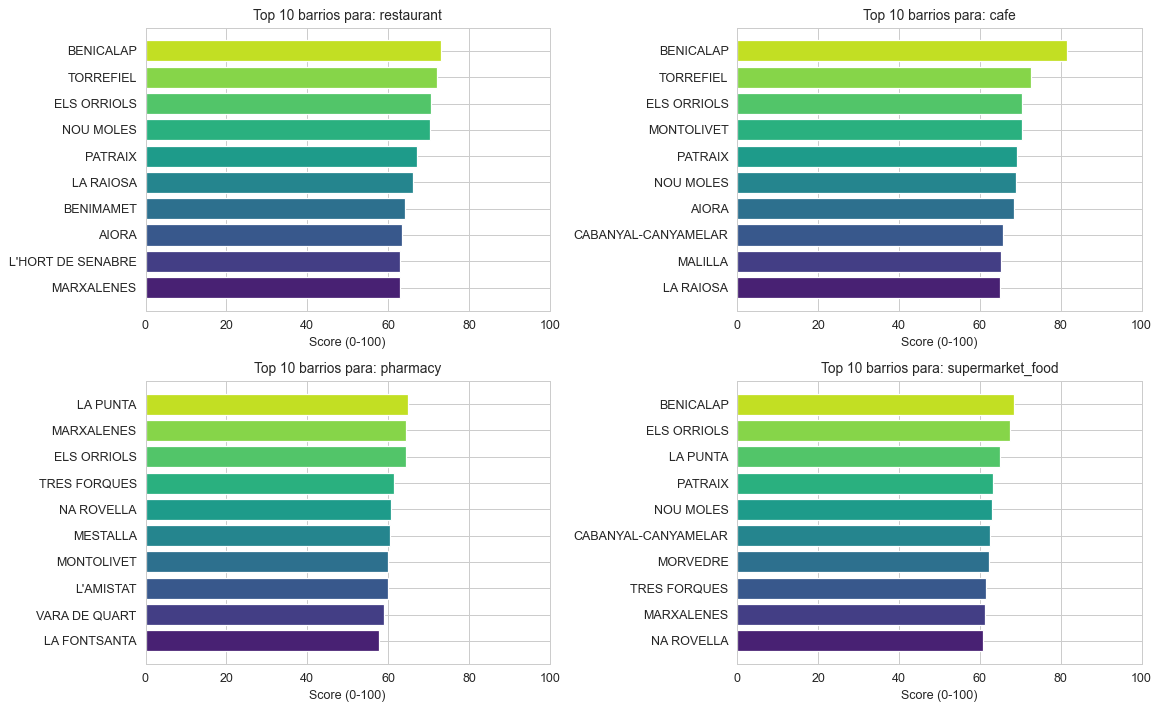

In [18]:
# Visualización: comparar score por sector
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sectores_demo = ['restaurant', 'cafe', 'pharmacy', 'supermarket_food']

for ax, sec in zip(axes.flat, sectores_demo):
    if f'n_locales_{sec}' in df.columns:
        rank = calcular_score_emprendedor(df, sec).head(10)
        colors = sns.color_palette('viridis', len(rank))
        ax.barh(rank['nombre'][::-1], rank['score'][::-1], color=colors)
        ax.set_xlabel('Score (0-100)')
        ax.set_title(f'Top 10 barrios para: {sec}', fontsize=11)
        ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

## 7. Tema 3 — Explicabilidad con SHAP (XAI)

Para el panel del Ayuntamiento (Perfil B), cuando un barrio se marca como "Oferta Insuficiente" la app debe justificarlo. SHAP nos da los pesos exactos de cada variable en la predicción.

Entrenamos el XGBoost en todo el dataset (ya validado con CV) y calculamos los SHAP values.

In [19]:
# Entrenar XGBoost final en TODO el dataset
xgb_final = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_final.fit(X, y)

# Explainer SHAP (rápido para tree models)
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X)

print(f'SHAP values calculados para {len(X)} barrios x {X.shape[1]} features')

SHAP values calculados para 87 barrios x 51 features


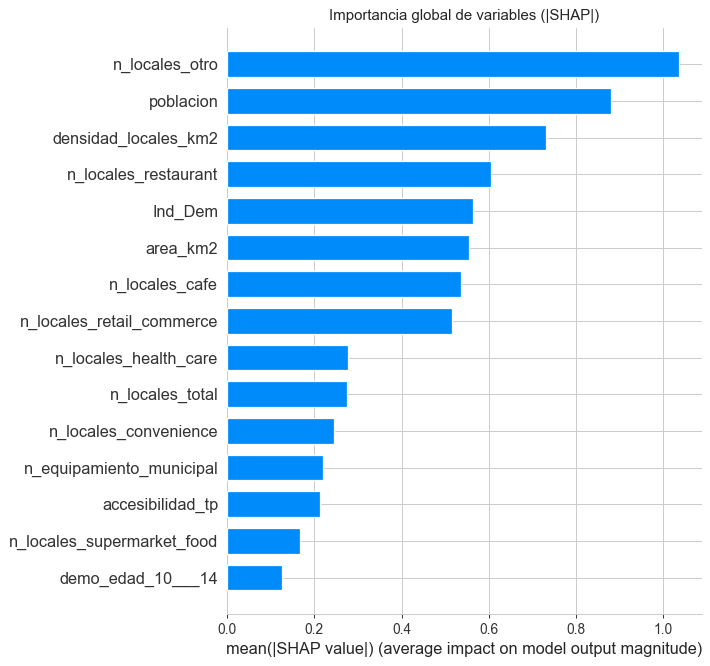

In [20]:
# Importancia global de features
fig = plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X, plot_type='bar', max_display=15, show=False)
plt.title('Importancia global de variables (|SHAP|)')
plt.tight_layout()
plt.show()

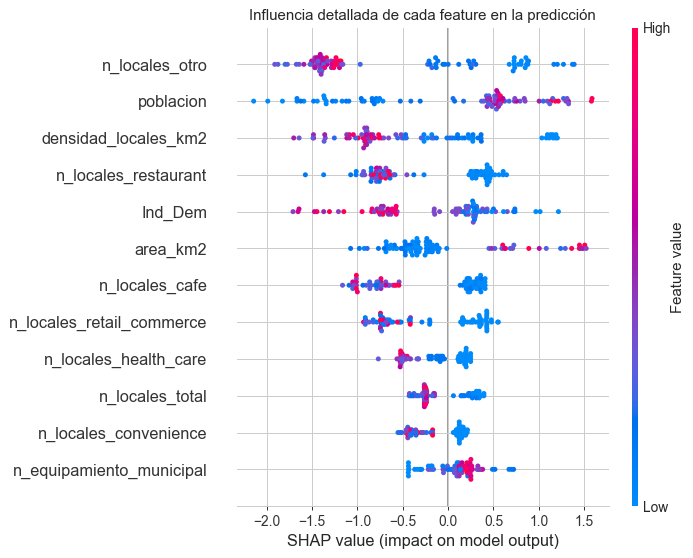

In [21]:
# Beeswarm: cómo influye cada feature en la predicción
fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X, max_display=12, show=False)
plt.title('Influencia detallada de cada feature en la predicción')
plt.tight_layout()
plt.show()

Barrio analizado: LA CREU COBERTA
Predicción del modelo: oferta_insuficiente = 1
Probabilidad: 0.976


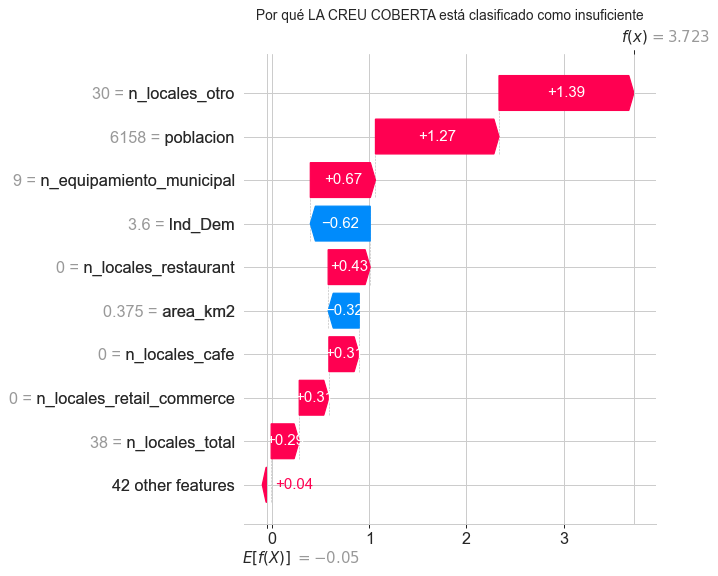

In [22]:
# Ejemplo XAI: explicación local de un barrio concreto
# Tomamos un barrio clasificado como insuficiente para ver POR QUÉ
barrios_insuf = df[df['oferta_insuficiente'] == 1].index.tolist()
idx_ejemplo = barrios_insuf[0]  # primer barrio insuficiente
nombre_ejemplo = df.loc[idx_ejemplo, 'nombre']

# Encontrar posición en X (puede no coincidir con idx_ejemplo si hubo filtrado)
pos = X.index.get_loc(idx_ejemplo)

print(f'Barrio analizado: {nombre_ejemplo}')
print(f'Predicción del modelo: oferta_insuficiente = {xgb_final.predict(X.iloc[[pos]])[0]}')
print(f'Probabilidad: {xgb_final.predict_proba(X.iloc[[pos]])[0, 1]:.3f}')

# Waterfall plot: explicación local
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[pos],
        base_values=explainer.expected_value,
        data=X.iloc[pos].values,
        feature_names=X.columns.tolist()
    ),
    max_display=10, show=False
)
plt.title(f'Por qué {nombre_ejemplo} está clasificado como insuficiente', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Serialización de modelos para la app Streamlit

Guardamos los modelos entrenados, el explainer SHAP y la función del score como `.pkl` para que la app pueda cargarlos sin reentrenar.

In [23]:
# Entrenamos los modelos finales en TODO el dataset (ya validados por CV)
rf_final = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=3,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf_final.fit(X, y)

stack_final = StackingClassifier(
    estimators=[('rf', rf_final), ('xgb', xgb_final)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    cv=cv, n_jobs=-1
)
stack_final.fit(X, y)

# Guardamos todo
joblib.dump(rf_final,    MODELS_DIR / 'modelo_rf.pkl')
joblib.dump(xgb_final,   MODELS_DIR / 'modelo_xgb.pkl')
joblib.dump(stack_final, MODELS_DIR / 'modelo_stacking.pkl')
joblib.dump(explainer,   MODELS_DIR / 'shap_explainer.pkl')

# Y la lista de features para que la app sepa qué columnas pasar al modelo
joblib.dump(list(X.columns), MODELS_DIR / 'feature_names.pkl')

print('Modelos guardados en ./models/:')
for f in MODELS_DIR.iterdir():
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:25s}  ({size_kb:.1f} KB)')

Modelos guardados en ./models/:
  feature_names.pkl          (1.0 KB)
  modelo_rf.pkl              (483.4 KB)
  modelo_stacking.pkl        (1345.4 KB)
  modelo_xgb.pkl             (176.7 KB)
  shap_explainer.pkl         (443.8 KB)


In [24]:
# Verificación: cargar y predecir como hará la app
modelo_cargado = joblib.load(MODELS_DIR / 'modelo_stacking.pkl')
feat_names = joblib.load(MODELS_DIR / 'feature_names.pkl')

# Predicción sobre los primeros 5 barrios
preds  = modelo_cargado.predict(X[feat_names].head(5))
probas = modelo_cargado.predict_proba(X[feat_names].head(5))[:, 1]

resultado = pd.DataFrame({
    'barrio': df.loc[X.head(5).index, 'nombre'].values,
    'prediccion': preds,
    'prob_insuficiente': probas.round(3)
})
print('Test de carga: predicciones sobre los 5 primeros barrios')
print(resultado.to_string(index=False))

Test de carga: predicciones sobre los 5 primeros barrios
            barrio  prediccion  prob_insuficiente
   LA CREU COBERTA           1              0.829
LA FONTETA S.LLUIS           0              0.410
      CAMI DE VERA           0              0.299
         BENIMAMET           1              0.801
         BENIFERRI           0              0.452


## 9. Resumen para el informe

### Cobertura de los temas del curso

| Tema | Concepto | Aplicación en GeoMarket-VLC |
|------|----------|----------------------------|
| 1 | Model Evaluation con datos desbalanceados | F1/ROC-AUC vs Accuracy, matriz de confusión, coste asimétrico de falsos negativos |
| 2 | Hybrid Models / Ensembles | Stacking de RF + XGBoost con meta-modelo Logistic Regression |
| 3 | Reliable Models / XAI | SHAP values: importancia global + explicaciones locales por barrio |

### Archivos generados para la app Streamlit
- `models/modelo_stacking.pkl` — clasificador principal
- `models/modelo_xgb.pkl` — para SHAP (más rápido que stacking)
- `models/shap_explainer.pkl` — generador de explicaciones
- `models/feature_names.pkl` — orden exacto de columnas que esperan los modelos

### Siguientes pasos
- Construir la app Streamlit con dos pestañas (Emprendedor / Planificador)
- Añadir sliders interactivos para el simulador de escenarios (Tema 3 - causalidad)
- Cuando los compañeros añadan features de turismo, basta con re-ejecutar este notebook